# One-Sample t-Test and Confidence Interval for the Mean

The **one-sample t-test** tests whether a population mean equals a hypothesised value μ₀. It is the most fundamental parametric hypothesis test.

| Property | Value |
|---|---|
| **H₀** | μ = μ₀ |
| **H₁** | μ ≠ μ₀ (two-tailed), μ > μ₀, or μ < μ₀ |
| **Test statistic** | t = (x̄ − μ₀) / (s / √n) |
| **Distribution** | t(n−1) under H₀ |
| **Assumptions** | Data approximately normal (or n ≥ 30 by CLT) |
| **95% CI** | x̄ ± t(α/2, n−1) · s/√n |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

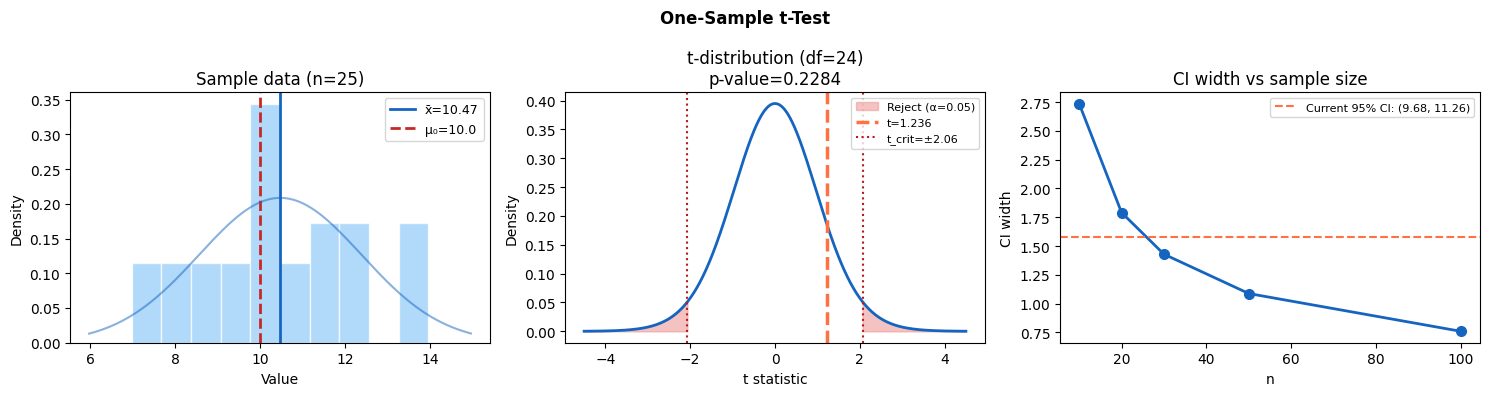

x̄=10.4730, s=1.9131, n=25
t-statistic: 1.2362
p-value: 0.2284  → Fail to reject H₀ at α=0.05
95% CI: (9.6833, 11.2627)


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('One-Sample t-Test', fontsize=12, fontweight='bold')

# Panel 1: sample data vs null hypothesis
n = 25
mu_0 = 10.0
data = np.random.normal(10.8, 2.0, n)
x_bar = data.mean(); s = data.std(ddof=1)
se = s / np.sqrt(n)
t_stat = (x_bar - mu_0) / se
p_val = 2 * stats.t.sf(abs(t_stat), df=n-1)

x_range = np.linspace(data.min()-1, data.max()+1, 300)
axes[0].hist(data, bins=10, density=True, color='#90CAF9', edgecolor='white', alpha=0.7)
axes[0].axvline(x_bar, color='#1565C0', lw=2, label=f'x̄={x_bar:.2f}')
axes[0].axvline(mu_0, color='#C62828', lw=2, ls='--', label=f'μ₀={mu_0}')
axes[0].plot(x_range, stats.norm(x_bar, s).pdf(x_range), color='#1565C0', lw=1.5, alpha=0.5)
axes[0].set_title(f'Sample data (n={n})')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Panel 2: t-distribution with rejection region
df = n - 1
t_range = np.linspace(-4.5, 4.5, 500)
t_pdf = stats.t.pdf(t_range, df)
t_crit = stats.t.ppf(0.975, df)
axes[1].plot(t_range, t_pdf, color='#1565C0', lw=2)
axes[1].fill_between(t_range, t_pdf, where=t_range >= t_crit, color='#EF9A9A', alpha=0.6, label=f'Reject (α=0.05)')
axes[1].fill_between(t_range, t_pdf, where=t_range <= -t_crit, color='#EF9A9A', alpha=0.6)
axes[1].axvline(t_stat, color='#FF7043', lw=2.5, ls='--', label=f't={t_stat:.3f}')
axes[1].axvline(t_crit, color='#B71C1C', lw=1.5, ls=':', label=f't_crit=±{t_crit:.2f}')
axes[1].axvline(-t_crit, color='#B71C1C', lw=1.5, ls=':')
axes[1].set_title(f't-distribution (df={df})\np-value={p_val:.4f}')
axes[1].set_xlabel('t statistic'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Panel 3: confidence interval vs null
sample_sizes = [10, 20, 30, 50, 100]
ci_widths = []
for ni in sample_sizes:
    t_c = stats.t.ppf(0.975, ni-1)
    ci_widths.append(2 * t_c * s / np.sqrt(ni))

axes[2].plot(sample_sizes, ci_widths, 'o-', color='#1565C0', lw=2, ms=7)
ci_lo = x_bar - t_crit * se
ci_hi = x_bar + t_crit * se
axes[2].axhline(mu_0 - ci_lo + (ci_hi - mu_0), color='#FF7043', lw=1.5, ls='--',
                label=f'Current 95% CI: ({ci_lo:.2f}, {ci_hi:.2f})')
axes[2].set_title('CI width vs sample size')
axes[2].set_xlabel('n'); axes[2].set_ylabel('CI width')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

t_stat2, p_val2 = stats.ttest_1samp(data, mu_0)
print(f'x̄={x_bar:.4f}, s={s:.4f}, n={n}')
print(f't-statistic: {t_stat2:.4f}')
print(f'p-value: {p_val2:.4f}  → {"Reject H₀" if p_val2 < 0.05 else "Fail to reject H₀"} at α=0.05')
print(f'95% CI: ({ci_lo:.4f}, {ci_hi:.4f})')

## Key Takeaways

| | |
|---|---|
| **t = (x̄−μ₀)/(s/√n)** | Standardised distance from sample mean to null value |
| **Degrees of freedom** | n−1; as n→∞, t approaches Normal(0,1) |
| **p-value** | Probability of seeing a result this extreme if H₀ were true |
| **CI and test agree** | Reject H₀ ⟺ μ₀ falls outside the 95% CI |
| **Paired t-test** | Apply one-sample t-test to differences: d = y_after − y_before |
| **Normality** | Assumed; robust for n ≥ 30 by CLT; check with Q-Q or Shapiro-Wilk |